In [ ]:
"""
    鸢尾花数据集 
    四个特征：
        花萼长度
        花萼宽度
        花瓣长度
        花瓣宽度

    
    三种品种分类:
        山鸢尾 
        变色鸢尾
        维吉尼亚鸢尾


"""


In [1]:
!uv pip show scikit-learn

Using Python 3.12.13 environment at: D:\Work\OldBack\Personal\Github Repository\ai_python_practice_questions\quetions\.venv


In [2]:
!uv pip install scikit-learn

Using Python 3.12.13 environment at: D:\Work\OldBack\Personal\Github Repository\ai_python_practice_questions\quetions\.venv
Resolved 6 packages in 3.13s
 Downloaded scikit-learn
 Downloaded scipy
Prepared 5 packages in 24.47s
         If the cache and target directories are on different filesystems, hardlinking may not be supported.
         If this is intentional, set `export UV_LINK_MODE=copy` or use `--link-mode=copy` to suppress this warning.
Installed 5 packages in 56.79s
 + joblib==1.5.3
 + narwhals==2.22.1
 + scikit-learn==1.9.0
 + scipy==1.17.1
 + threadpoolctl==3.6.0


In [13]:
from sklearn.datasets import load_iris

# 加载鸢尾花数据集

iris_dataset = load_iris()
print(iris_dataset.keys())
print(iris_dataset.data[0]) # 特征矩阵 花萼长度 花萼宽度 花瓣长度 花瓣宽度
print(iris_dataset.target[0])
print(iris_dataset.feature_names)
print(iris_dataset.target_names)

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])
[5.1 3.5 1.4 0.2]
0
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
['setosa' 'versicolor' 'virginica']


In [7]:
# 保存 csv文件 需要使用 pandas
!uv pip show pandas

Using Python 3.12.13 environment at: D:\Work\OldBack\Personal\Github Repository\ai_python_practice_questions\quetions\.venv


In [8]:
!uv pip install pandas

Using Python 3.12.13 environment at: D:\Work\OldBack\Personal\Github Repository\ai_python_practice_questions\quetions\.venv
Resolved 5 packages in 3.54s
 Downloaded pandas
Prepared 1 package in 4.76s
         If the cache and target directories are on different filesystems, hardlinking may not be supported.
         If this is intentional, set `export UV_LINK_MODE=copy` or use `--link-mode=copy` to suppress this warning.
Installed 1 package in 16.85s
 + pandas==3.0.3


In [14]:
# 保存为 csv文件
import pandas as pd

df = pd.DataFrame(data= iris_dataset.data, columns= iris_dataset.feature_names)
df['species'] = iris_dataset.target_names[iris_dataset.target]
df.to_csv('iris_dataset.csv', index= False)


In [18]:
# 鸢尾花基本信息

print(f"数据集行数：{iris_dataset.data.shape}")

print(f"前10行数据：{df.head(10)}")

print(f"统计数据:{df.describe()}")

print(f"各类别样本数量：{df['species'].value_counts().sort_index()}")

数据集行数：(150, 4)
前10行数据：   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   
5                5.4               3.9                1.7               0.4   
6                4.6               3.4                1.4               0.3   
7                5.0               3.4                1.5               0.2   
8                4.4               2.9                1.4               0.2   
9                4.9               3.1                1.5               0.1   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  
5  setosa  
6  setosa  
7  setosa  


In [19]:
!uv pip show matplotlib

Name: matplotlib
Version: 3.10.9
Location: D:\Work\OldBack\Personal\Github Repository\ai_python_practice_questions\quetions\.venv\Lib\site-packages
Requires: contourpy, cycler, fonttools, kiwisolver, numpy, packaging, pillow, pyparsing, python-dateutil
Required-by:


Using Python 3.12.13 environment at: D:\Work\OldBack\Personal\Github Repository\ai_python_practice_questions\quetions\.venv


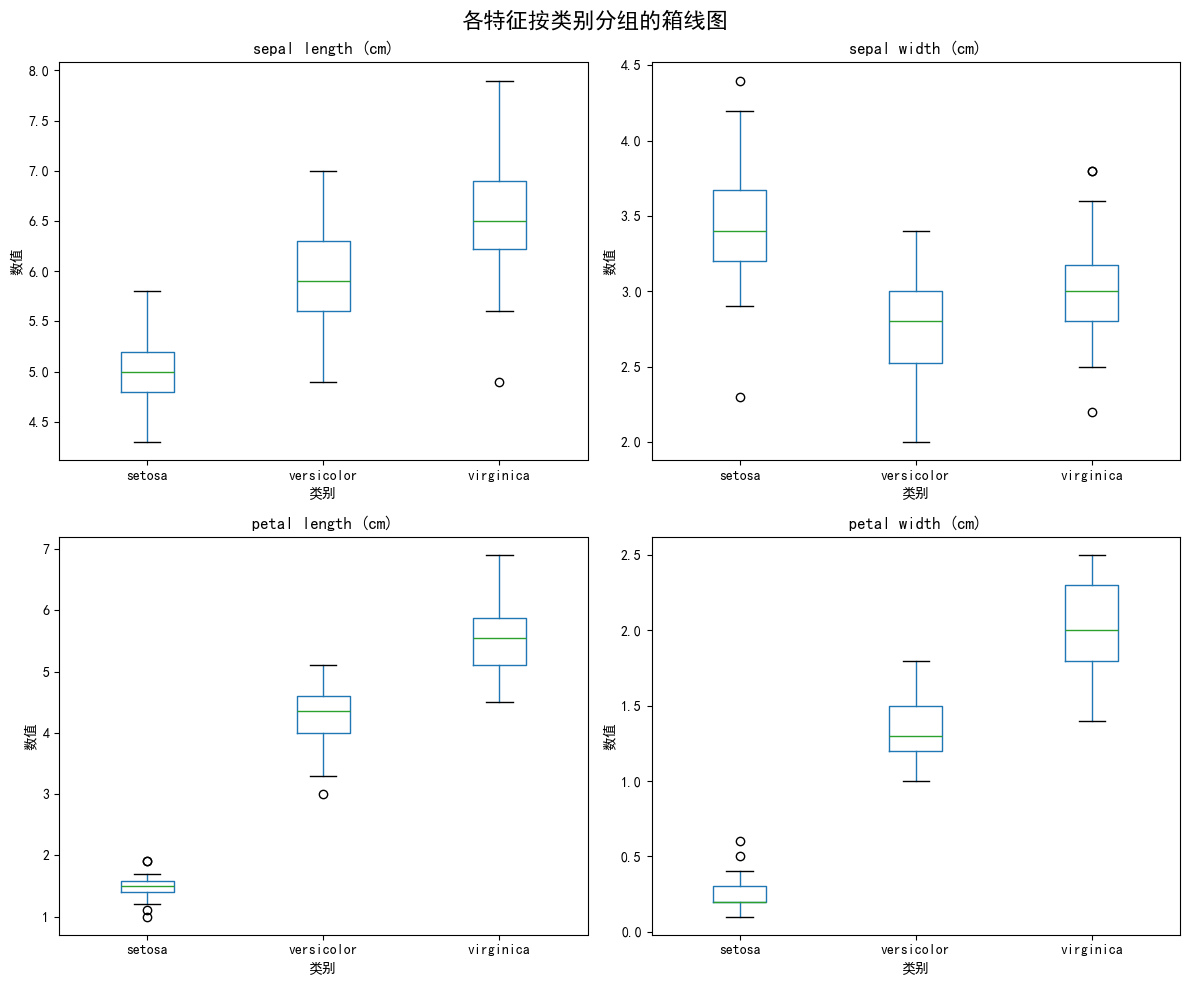

In [ ]:
# 箱线图 各个特征
import matplotlib.pyplot as plt

# 设置中文
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for i, feature in enumerate(iris_dataset.feature_names):
    row = i // 2
    col = i % 2
    ax = axes[row, col]
    df.boxplot(column=feature, by= 'species', ax= ax, grid=False)
    ax.set_title(feature)
    ax.set_xlabel('类别')
    ax.set_ylabel('数值')
plt.suptitle('各特征按类别分组的箱线图', size= 16)
plt.tight_layout()
plt.show()

In [ ]:
# 鸢尾花数据集划分

# sklearn.model_selection 负责拆分数据，选择模型和调整参数
# train_test_split 数据拆分函数
from sklearn.model_selection import train_test_split

# test_size = 0.2 表示 20%作为测试集 80%作为训练集
# random_state = 1 表示 随机种子，固定保证结果可重复
train_feature, test_feature, train_label, test_label = train_test_split(iris_dataset.data, iris_dataset.target, test_size= 0.2, random_state=1)
print(f"训练集特征形状：{train_feature.shape}")
print(f"测试集特征形状：{test_feature.shape}")
print(f"训练集标签形状:{train_label.shape}")
print(f"测试集标签形状：{test_label.shape}")


训练集特征形状：(120, 4)
测试集特征形状：(30, 4)
训练集标签形状:(120,)
测试集标签形状：(30,)


In [28]:
# 整个过程统一三步 创建模型 -> 训练模型 -> 预测与评估
# 
# 机器学习：从数据中学习规律，对新数据进行预测
# 监督学习：训练数据包含输入特征和已知的类别标签
# 分类任务：预测样本属于哪个离散的类别

# 机器学习领域 - 监督学习的分类算法
# 逻辑回归 LR：二分类(默认)，多分类，输出样本属于某一类别的概率值。举例：告诉你一朵花有95%概率是山鸢尾，5%的概率是变色鸢尾
# 支持向量机 SVM：分类(SVC)，回归(SVR)和异常检测。例如：直接判断这朵话属于 维吉尼亚鸢尾，并给出"决策边界"

# 先定义模型

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# 引入 分层K折，交叉验证
from sklearn.model_selection import StratifiedKFold, cross_val_score

# 创建模型
models = {
    # 入参: 
    # C 正则化强度的倒数 默认1.0
    # solver 优化算法 lbfgs 拟牛顿法的一种，适合中小数据集，处理多分类问题，版本的默认求解器之一
    # max_iter 求解器的最大迭代次数, 默认100
    'LR': LogisticRegression(C=1.0, solver='lbfgs', max_iter=100),
    # 入参:
    # C 惩罚系数 默认1.0
    # kernel 核函数
    # gamma 核函数系数 

    'SVC' : SVC(C= 1.0, kernel='rbf', gamma='auto')
}

# 训练模型
results = []
names = []
for name, model in models.items():
    # 分层K折交叉验证
    # 入参：
    # n_splits 折数，数据集被划分成多少份
    # shuffle 是否在划分前打乱数据
    skf = StratifiedKFold(n_splits= 10, shuffle= True, random_state= 1)
    scores = cross_val_score(model, train_feature, train_label, cv= skf, scoring='accuracy')
    results.append(scores)
    names.append(name)
    # mean 平均值 std 计算标准值
    print(f"{name}: 平均准确率：{scores.mean():.4f} (*/- {scores.std():.4f})")

d:\Work\OldBack\Personal\Github Repository\ai_python_practice_questions\quetions\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LR: 平均准确率：0.9667 (*/- 0.0408)
SVC: 平均准确率：0.9833 (*/- 0.0333)


C:\Users\102746\AppData\Local\Temp\ipykernel_30556\3770786865.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(results, labels=names)


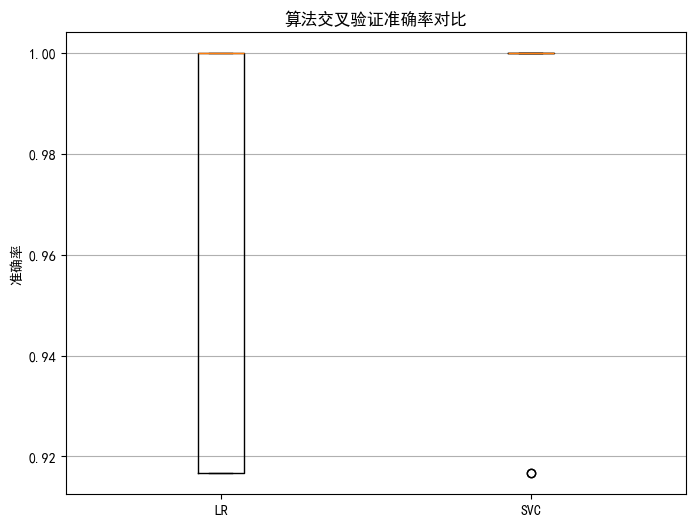

In [29]:
# 绘制平均准确率和标准差

plt.figure(figsize=(8, 6))
plt.boxplot(results, labels=names)
plt.title('算法交叉验证准确率对比')
plt.ylabel('准确率')
plt.grid(axis = 'y')
plt.show()